# Dispatchoptimalisatie van batterijopslag voor energiearbitrage en piekafvlakking

## Managementsamenvatting

Een netgekoppelde commerciële locatie exploiteert een lithium-ionbatterij van 2 MW / 8 MWh naast een gemeten elektrische belasting. De locatie wordt op twee manieren gefactureerd: een **energieprijs** per uur op de day-ahead-markt ($/MWh) en een maandelijkse **capaciteitsheffing** op het enkele hoogste netafname-interval ($/MW). De assetmanager moet uur na uur beslissen wanneer hij de batterij oplaadt (goedkope energie kopen en de netafname verhogen) en wanneer hij ontlaadt (dure energie compenseren en de netafname verlagen). Twee waardestromen concurreren: **energiearbitrage** (goedkoop 's nachts kopen, ontladen tijdens de avondpiek) en **piekafvlakking** (het gefactureerde netmaximum begrenzen). Opladen is niet gratis — het retourrendement betekent dat ruwweg 10% van de opgeslagen energie verloren gaat — dus het schema is een echte optimalisatie, geen heuristiek.

Dit notebook bouwt de beslissing van begin tot eind. Het synthetiseert eerst een realistische 24-uurs day-ahead-prijscurve (met ochtend- en avondpieken plus een nachtelijk dal) en een gecorreleerd locatiebelastingsprofiel, en profileert beide met **PROC MEANS** en een robuuste **PROC UNIVARIATE** 2,5/97,5-percentielprijsband. De kern is een lineair programma in **PROC OPTMODEL**: beslissingsvariabelen voor het uurlijkse laden, ontladen en de laadtoestand, plus een gefactureerde-piekvariabele, onderworpen aan een cumulatieve laadtoestandsbalans (met afzonderlijk laad-/ontlaadrendement), vermogens- en capaciteitslimieten, en een piekdefinitiebeperking. De doelstelling maximaliseert de arbitragemarge netto van de capaciteitsheffing. **PROC SQL** kwantificeert vervolgens de basislijn-versus-geoptimaliseerde kosten, en drie **PROC SGPLOT**-panelen visualiseren het laad-/ontlaadschema tegen de prijs, het laadtoestandstraject en het afgevlakte netafnameprofiel.

**Resultaat op de synthetische dag:** de optimalisator vult de batterij tijdens de goedkoopste nachtelijke uren, ontlaadt in zowel de ochtend- als de avondprijspiek, laadt weer op door het middagdal, en — cruciaal — houdt zijn laadvermogen terug zodat het nooit een nieuwe netpiek creëert. De dagelijkse energiekosten dalen van **\$2,903.78 naar \$2,528.43** — **\$375.34 (12,9%) aan arbitragebesparing** — terwijl het gefactureerde netmaximum daalt van **3,59 MW naar 3,43 MW** (ongeveer **0,16 MW**), wat bij de aangenomen dagelijks-aandeel-capaciteitsheffing nog eens **\$18.98** waard is. Hetzelfde model schaalt naar langere horizonten, meerdere prijsscenario's of degradatiebewuste cycli door eenvoudigweg de indexset en beperkingen uit te breiden.

## Gegevensbronnen

Alle gegevens zijn **synthetisch**, inline gegenereerd in de eerste codecel met `CALL STREAMINIT(20260605)` voor reproduceerbaarheid. Geen externe bestanden of netwerktoegang. Eén dataset, `price_load`, met 24 uurlijkse rijen die één bedrijfsdag vertegenwoordigen.

| Variabele | Type | Eenheden | Beschrijving |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Uur van de bedrijfsdag (horizonindex) |
| `price` | num | $/MWh | Day-ahead-energieprijs: nachtelijk dal, ochtend- + avondpieken, met Gaussische ruis (met ondergrens $5) |
| `load` | num | MW | Elektrische vraag van de locatie, gecorreleerd met dagelijkse activiteit (met ondergrens 0,3 MW) |
| `day_type` | char | — | Tariefvenstervlag: `PeakTOU` (uren 17–21) versus `OffPeak`, gebruikt voor de piek/dal-prijsspreidingssamenvatting |

Batterijparameters zijn vaste modelconstanten binnen PROC OPTMODEL: 8 MWh bruikbare capaciteit, 2 MW maximaal laad-/ontlaadvermogen, 0,95 laad- en 0,95 ontlaadrendement (~90% retour), begincapaciteitstoestand 0 MWh, en een capaciteitsheffing van \$120/MW toegepast op de gefactureerde netpiek van de dag (het dagelijks geamortiseerde aandeel van een maandelijkse capaciteitsheffing).

# Dispatchoptimalisatie van batterijopslag
## Energiearbitrage en piekafvlakking voor een netgekoppelde locatie

Een commerciële locatie exploiteert een **batterij van 2 MW / 8 MWh** achter de meter. Zijn elektriciteitsrekening heeft twee delen: een **energieprijs** per uur ($/MWh) en een maandelijkse **capaciteitsheffing** op het enkele hoogste netafname-interval ($/MW). De exploitant wil een uurlijks laad-/ontlaadschema dat twee waardestromen tegelijk vangt:

- **Arbitrage** — sla goedkope nachtelijke energie op, geef die vrij tijdens dure piekuren.
- **Piekafvlakking** — ontlaad tijdens de vraagpiek om het gefactureerde netmaximum te verlagen.

Omdat het retourrendement ~10% van de opgeslagen energie verliest, is de afweging niet triviaal en verdient hij een echte optimalisatie. We formuleren het als een lineair programma in **PROC OPTMODEL**, en kwantificeren en visualiseren vervolgens het resultaat.

> Alle onderstaande gegevens zijn synthetisch en inline gegenereerd — het notebook is volledig zelfstandig en draait in enkele seconden.

## 1. Genereer een synthetisch day-ahead-prijs- en belastingsprofiel

We bouwen één bedrijfsdag (24 uurlijkse rijen). De prijscurve heeft een nachtelijk dal en ochtend- + avondpieken; de locatiebelasting is gecorreleerd met dagelijkse activiteit. Een vaste seed houdt de run reproduceerbaar. We labelen ook het wettelijke time-of-use-piekvenster, zodat we later de piek/dal-spreiding kunnen samenvatten.

In [1]:
GEGEVENS price_load;
    CALL streaminit(20260605);
    LENGTE day_type $7;
    DOE hour = 0 TOT 23;
        /* Dagcyclische energieprijs ($/MWh): ochtend- + avondpieken */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        ALS price < 5 DAN price = 5;

        /* Locatiebelasting (MW): nachtelijk dal, avondstijging */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        ALS LOAD < 0.3 DAN LOAD = 0.3;

        ALS hour >= 17 AND hour <= 21 DAN day_type = 'PeakTOU';
        ANDERS day_type = 'OffPeak';
        UITVOER;
    EINDE;
    VERWIJDEREN BASE;
    LABEL hour='Uur van de dag'
          price='Energieprijs ($/MWh)'
          LOAD='Locatiebelasting (MW)'
          day_type='Tariefvenster';
UITVOEREN;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profileer de prijs- en belastingsverdelingen

Voordat we optimaliseren, controleren we de invoer op plausibiliteit. De spreiding tussen de goedkoopste en duurste uren is wat arbitrage te gelde maakt, en de maximale belasting verankert de piekafvlakkingskans.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=price_load n mean std MIN MAX maxdec=2;
    VARIABELE price LOAD;
    TITEL 'Profiel van prijs- en belastingsverdelingen';
UITVOEREN;

                                      Profiel van prijs- en belastingsverdelingen                                       

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------------
 price     Energieprijs ($/MWh)        24       46.29       15.81       18.57       79.27
 LOAD      Locatiebelasting (MW)       24        2.47        0.48        1.71        3.59
 ----------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Prijsspreiding piek versus dal

Groeperen op de time-of-use-vlag toont hoeveel rijker de piekuren zijn dan de dalbasislijn — het structurele signaal dat de batterij benut.

In [3]:
PROCEDURE GEMIDDELDEN GEGEVENS=price_load mean MIN MAX maxdec=2;
    KLASSE day_type;
    VARIABELE price;
    TITEL 'Prijsspreiding piek versus dal';
UITVOEREN;

                                             Prijsspreiding piek versus dal                                             

                                                  The MEANS Procedure

                                    Analysis Variable : price Energieprijs ($/MWh)

                                                  N
                               Tariefvenster    Obs       Mean      Minimum      Maximum
                               ---------------------------------------------------------
                               OffPeak           19      40.46        18.57        54.89
                               PeakTOU            5      68.45        54.88        79.27
                               ---------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robuuste prijsband (2,5 / 97,5-percentielen)

We karakteriseren de prijsstaarten met een 2,5 / 97,5-percentielband. **PROC UNIVARIATE** met `PCTLPTS=` berekent willekeurige percentielen netjes, wat het juiste instrument is voor fractionele percentielen.

In [4]:
PROCEDURE UNIVARIATE GEGEVENS=price_load NOPRINT;
    VARIABELE price;
    UITVOER out=price_band pctlpts=2.5 97.5 pctlpre=p_;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=price_band noobs label;
    LABEL p_2_5='Prijs 2,5e percentiel ($/MWh)'
          p_97_5='Prijs 97,5e percentiel ($/MWh)';
    TITEL 'Robuuste prijsband (2,5 / 97,5-percentielen)';
UITVOEREN;

                                      Robuuste prijsband (2,5 / 97,5-percentielen)                                      

Prijs 2,5e percentiel ($/MWh)  Prijs 97,5e percentiel ($/MWh)
                        18.57                           79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. De dispatchoptimalisatie (lineair programma)

We lezen de uurlijkse prijs en belasting in PROC OPTMODEL en declareren:

- `chg[h]`, `dis[h]` — uurlijks laad-/ontlaadvermogen (MW), begrensd door de 2 MW-omvormernominale waarde.
- `soc[h]` — laadtoestand (MWh), begrensd door de 8 MWh bruikbare capaciteit.
- `peak` — het gefactureerde netmaximum (MW).

**Beperkingen.** `soc_balance` accumuleert netto energie door elk uur met afzonderlijk laad-/ontlaadrendement (een lopende-somvorm van de uurlijkse recurrentie). `peak_def` dwingt `peak` om de netto netafname van elk uur te domineren, zodat minimaliseren ervan de capaciteitsheffing afvlakt.

**Doelstelling.** Maximaliseer de arbitragemarge — `price × (discharge − charge)` gesommeerd over de dag — minus de capaciteitsheffing op de gefactureerde piek. We lossen op als een continu LP.

In [5]:
PROCEDURE optmodel;
    INSTELLEN HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ GEGEVENS price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Batterij: 8 MWh bruikbaar, 2 MW vermogen, ~90% retourrendement */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Capaciteitsheffing toegepast op de gefactureerde netpiek van deze dag ($/MW).
       Commerciele capaciteitsheffingen zijn maandelijks; 120 is de marginale
       waarde van het afvlakken van het netmaximum van vandaag zodra de
       maandelijkse heffing is geamortiseerd naar de dag. Ze is groot genoeg dat
       de optimalisator laadvermogen terughoudt in plaats van een nieuwe, hogere
       piek te creeren. */
    num demand_chg = 120;

    /* Beslissingsvariabelen (MW laden / ontladen, MWh laadtoestand) */
    VARIABELE chg{HOURS}  >= 0 <= p_max;
    VARIABELE dis{HOURS}  >= 0 <= p_max;
    VARIABELE soc{HOURS}  >= 0 <= capacity;
    VARIABELE peak        >= 0;   /* gefactureerde netpiek (MW) voor capaciteitsheffing */

    /* Netto netafname na batterijactie (MW) */
    impvar grid_mw{h in HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulatieve laadtoestand: energie in min energie uit tot en met uur h,
       met laad-/ontlaadrendement toegepast. Equivalent aan een uurlijkse
       recurrentie maar uitgedrukt als lopende som over voorgaande uren. */
    con soc_balance{h in HOURS}:
        soc[h] = soc0
                 + sum{k in HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Piekafvlakking: gefactureerde piek is de max netafname over de dag */
    con peak_def{h in HOURS}: peak >= grid_mw[h];

    /* Maximaliseer de energiearbitragemarge netto van de capaciteitsheffing */
    MAX net_value =
        sum{h in HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE GEGEVENS dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                      Robuuste prijsband (2,5 / 97,5-percentielen)                                      


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Het optimale uurlijkse schema

De opgeloste tabel toont laden verspreid over de goedkope nachtelijke en middaguren — gematigd tot ruwweg 1,0–1,7 MW zodat het nooit een nieuwe netpiek zet — ontladen geconcentreerd in de ochtend- en avondprijspieken, en de laadtoestand die een zinnige vul-en-vrijgeefcyclus tekent binnen de 8 MWh-limiet. De kolom `grid_mw` houdt een vlak plafond van ~3,43 MW aan door elk laaduur, het kenmerk van de bindende piekbeperking.

In [6]:
PROCEDURE AFDRUKKEN GEGEVENS=dispatch noobs label;
    VARIABELE hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    LABEL hour='Uur van de dag'
          price='Energieprijs ($/MWh)'
          LOAD='Locatiebelasting (MW)'
          charge_mw='Laden (MW)'
          discharge_mw='Ontladen (MW)'
          soc_mwh='Laadtoestand (MWh)'
          grid_mw='Netafname (MW)';
    TITEL 'Het optimale uurlijkse schema';
UITVOEREN;

                                             Het optimale uurlijkse schema                                              

Uur van de dag  Energieprijs ($/MWh)  Locatiebelasting (MW)  Laden (MW)  Ontladen (MW)  Laadtoestand (MWh)  Netafname (MW)
             0                 29.73                   1.99   1.4418421              0             1.36975       3.4318421
             1                 28.03                   2.16   1.2718421              0               2.578       3.4318421
             2                 21.87                      2   1.4318421              0             3.93825       3.4318421
             3                 18.57                   1.71   1.7218421              0               5.574       3.4318421
             4                 27.62                   2.13   1.3018421              0             6.81075       3.4318421
             5                 36.12                   2.18   1.2518421              0                   8       3.4318421
             6   


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Kern-KPI's: basislijn versus geoptimaliseerd

We vergelijken de niets-doen-basislijn (elk uur de prijs voor de ruwe belasting betalen) tegen de geoptimaliseerde netpositie, en rapporteren de arbitragebesparing, de verlaging van de gefactureerde piek, en de dollarwaarde van die verlaging bij de capaciteitsheffing — de twee hefbomen die de businesscase aandrijven.

In [7]:
PROCEDURE SQL;
    CREATE TABLE kpi AS
    SELECTEREN
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

PROCEDURE AFDRUKKEN GEGEVENS=kpi noobs label;
    LABEL base_energy_cost='Basislijn-energiekosten ($)'
          opt_energy_cost='Geoptimaliseerde energiekosten ($)'
          arbitrage_savings='Arbitragebesparing ($)'
          base_peak_mw='Basislijn-netpiek (MW)'
          opt_peak_mw='Geoptimaliseerde netpiek (MW)'
          peak_reduction_mw='Piekverlaging (MW)'
          demand_charge_savings='Capaciteitsheffingsbesparing ($)';
    TITEL "Kern-KPI's: basislijn versus geoptimaliseerd";
UITVOEREN;

                                             Het optimale uurlijkse schema                                              

                                      Kern-KPI's: basislijn versus geoptimaliseerd                                      

Basislijn-energiekosten ($)  Geoptimaliseerde energiekosten ($)  Arbitragebesparing ($)  Basislijn-netpiek (MW)  Geoptimaliseerde netpiek (MW)  Piekverlaging (MW)  Capaciteitsheffingsbesparing ($)
                  2903.7774                     2528.4335145526          375.3438854474                    3.59                      3.4318421           0.1581579                         18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Laad-/ontlaadschema tegen prijs

Laden (blauwe naalden) en ontladen (rode lijn met markeringen) delen de linker megawatt-as; de day-ahead-prijs (groen gestippeld) wordt op rechts afgelezen. Laden clustert in de goedkope nachtelijke en middaguren, terwijl ontladen afvuurt in de ochtend- en avondprijspieken — de visualisatie bevestigt dat de optimalisator laag koopt en hoog verkoopt.

                                      Kern-KPI's: basislijn versus geoptimaliseerd                                      




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


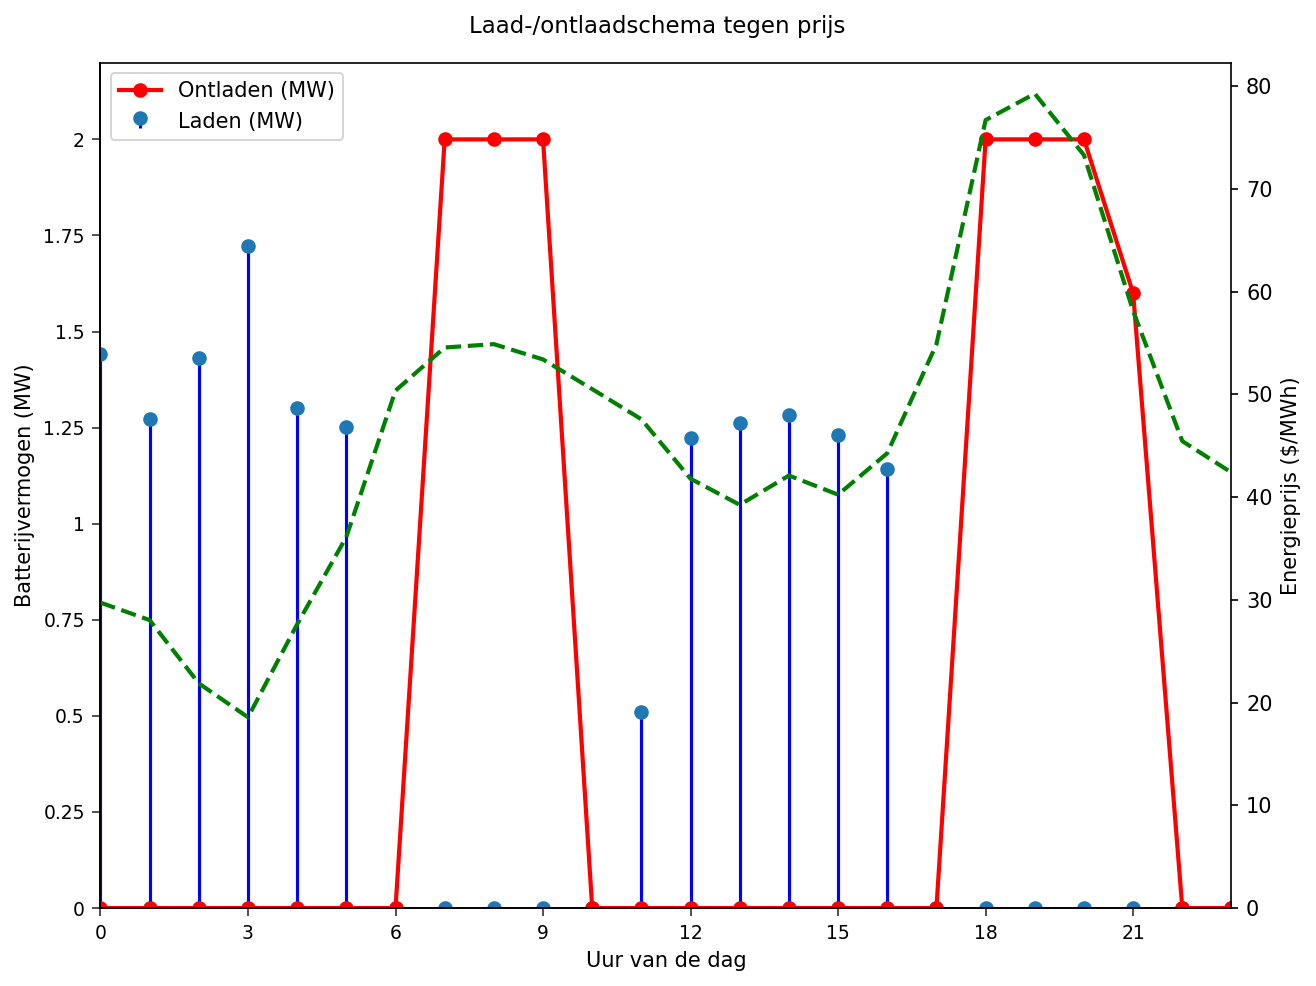

In [8]:
PROCEDURE SGPLOT GEGEVENS=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Laden (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Ontladen (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Prijs ($/MWh)";
    XAXIS label="Uur van de dag" VALUES=(0 TOT 23 VOLGENS 3);
    YAXIS label="Batterijvermogen (MW)" MIN=0 MAX=2.2;
    y2axis label="Energieprijs ($/MWh)" MIN=0;
    TITEL 'Laad-/ontlaadschema tegen prijs';
UITVOEREN;

## 9. Laadtoestandstraject

De opgeslagen energie stijgt terwijl de batterij zich 's nachts vult, loopt terug door elk ontlaadvenster, en overschrijdt nooit het bruikbare-capaciteitsplafond van 8 MWh (gestippelde referentie).

                                      Kern-KPI's: basislijn versus geoptimaliseerd                                      




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


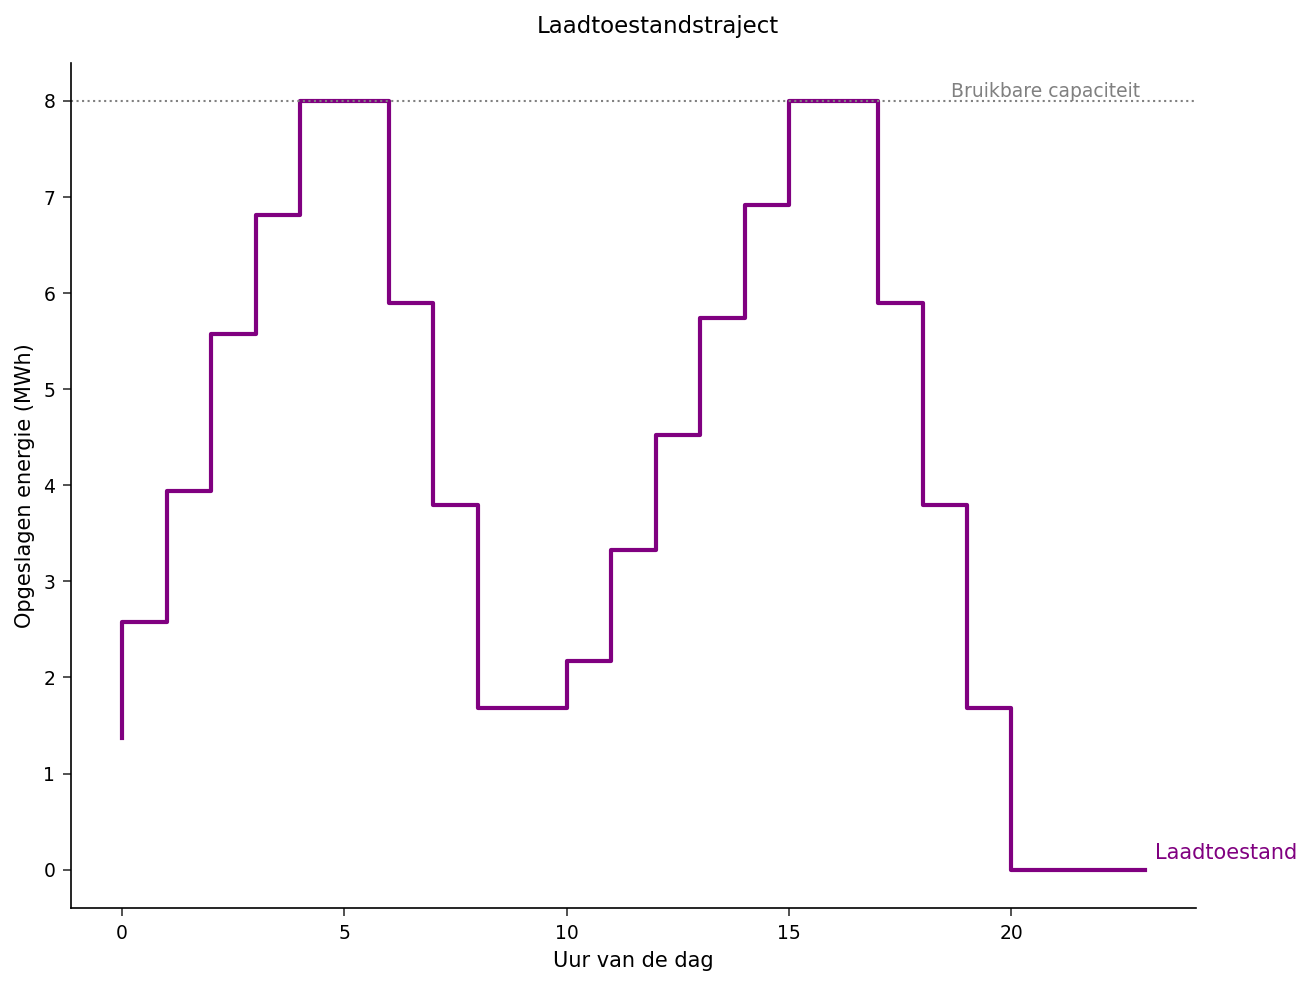

In [9]:
PROCEDURE SGPLOT GEGEVENS=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Laadtoestand";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        label="Bruikbare capaciteit";
    XAXIS label="Uur van de dag";
    YAXIS label="Opgeslagen energie (MWh)";
    TITEL 'Laadtoestandstraject';
UITVOEREN;

## 10. Netafname: voor versus na dispatch

De oranje lijn (netafname met de batterij) daalt ruim onder de gestippelde basislijnbelasting door de avondstijging (uren 18–21) — het piekafvlakkingseffect dat de capaciteitsheffing verlaagt. Tijdens de nachtelijke en middaglaadvensters stijgt hij, maar de optimalisator begrenst hem op een vlak plafond van ~3,43 MW dat *onder* de oorspronkelijke belastingspiek van 3,59 MW blijft, zodat laden goedkope energie koopt zonder een nieuw gefactureerd maximum te zetten.

                                      Kern-KPI's: basislijn versus geoptimaliseerd                                      




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


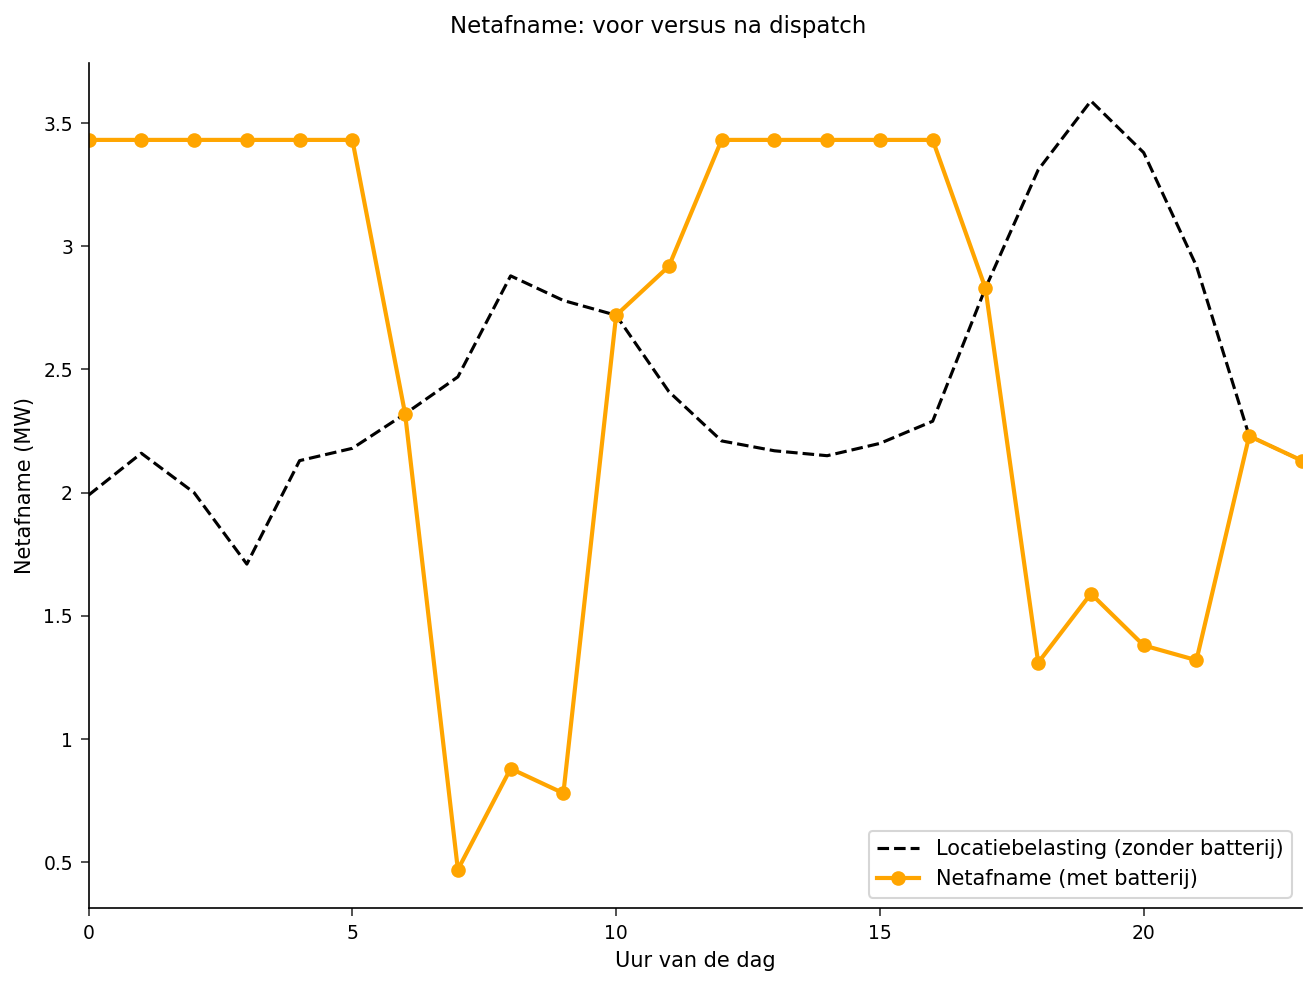

In [10]:
PROCEDURE SGPLOT GEGEVENS=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Locatiebelasting (zonder batterij)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Netafname (met batterij)";
    XAXIS label="Uur van de dag";
    YAXIS label="Netafname (MW)";
    TITEL 'Netafname: voor versus na dispatch';
UITVOEREN;

## Interpretatie en vervolgstappen

**Wat het model besloot.** Terwijl het retourrendement elke cyclus belast, vond de optimalisator toch duidelijke waarde: het vulde de batterij tijdens de goedkoopste nachtelijke uren, ontlaadde in de ochtendprijspiek (uren 7–9), laadde weer op door het middagprijsdal (uren 11–16), en ontlaadde opnieuw in de rijkste avondpiek (uren 18–21). Veelzeggend laadde het slechts op 1,0–1,7 MW in plaats van de volledige 2 MW-nominale waarde tijdens de nachtelijke vulling — vermogen terughoudend zodat de toegevoegde netafname de import nooit boven de belastingspiek van de dag duwde. De laadtoestand respecteerde te allen tijde zowel de 8 MWh-capaciteit als de 2 MW-vermogenslimiet.

**De businesscase.** De dagelijkse energiekosten daalden van **\$2,903.78 naar \$2,528.43** — **\$375.34 (12,9%)** aan arbitragebesparing — en het gefactureerde netmaximum daalde van **3,59 MW naar 3,43 MW** (ongeveer **0,16 MW**), wat nog eens **\$18.98** van de capaciteitsheffingsregel afsnijdt. Op jaarbasis over bedrijfsdagen plus de terugkerende capaciteitsheffingsverlaging is dit het soort marge dat een opslaginvestering onderbouwt.

**Waarom een LP het juiste instrument is.** Heuristieken ("laad onder de mediane prijs, ontlaad erboven") negeren rendementsverliezen, capaciteitskoppeling over uren, en het feit dat de capaciteitsheffing van één enkel interval afhangt — ze zouden 's nachts op vol vermogen laden en de gefactureerde piek *verhogen*, wat de piekafvlakkingswaarde vernietigt. PROC OPTMODEL vangt al deze in één declaratief model en levert het aantoonbaar optimale schema, dat hier opzettelijk het laadtempo matigt om de piek te beschermen.

**Het model uitbreiden.**

- **Langere horizonten / meerdere dagen** — verbreed de `HOURS`-indexset; voeg cyclusgrenzen tussen dagen toe.
- **Prijsonzekerheid** — los het LP op over meerdere prijsscenario's en middel de eerste-uur-beslissing (een rollend stochastisch beleid).
- **Batterijdegradatie** — voeg een doorvoerstrafterm of een beperking op cumulatieve cycli toe om arbitrage af te wegen tegen levensduur van de asset.
- **Frequentierespons / capaciteitsmarkten** — introduceer gereserveerde-marge-beperkingen zodat de batterij inkomsten uit ondersteunende diensten bovenop arbitrage kan stapelen.

Al deze zijn incrementele bewerkingen van hetzelfde OPTMODEL-blok — de hier vastgelegde structuur draagt ongewijzigd door.